# Clasificación Multi-Clase de Radiografías de Tórax con MLP
## ChestX6 Dataset — 6 Clases de Enfermedades Pulmonares

**Dataset:** ChestX6: Multi-Class X-ray Dataset (Kaggle)  
**Framework:** TensorFlow / Keras  
**Tarea:** Clasificación multiclase (6 clases)  
**Semana:** 1 — Implementación de Perceptrón Multicapa (MLP)
**Grupo2:** Nataly Lanchimba / Dario Herrera / Jordy Cevallos  

---
### Clases objetivo:
| # | Clase | Descripción |
|---|-------|-------------|
| 0 | Normal | Pulmones sanos, campos pulmonares claros |
| 1 | Pneumonia-Bacterial | Infección bacteriana, consolidaciones lobares densas |
| 2 | Pneumonia-Viral | Infecciones virales no-COVID, infiltrados intersticiales |
| 3 | COVID-19 | SARS-CoV-2, opacidades bilaterales en vidrio esmerilado |
| 4 | Tuberculosis | Infección por M. tuberculosis, cavitaciones en lóbulos superiores |
| 5 | Emphysema | EPOC, hiperinflación y diafragma aplanado |

---
## 1. Instalación y Configuración del Entorno

In [1]:
# Instalar kagglehub si no está disponible
!pip install kagglehub -q
!pip install scikit-learn matplotlib seaborn tensorflow -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
roboflow 1.1.61 requires filetype, which is not installed.
roboflow 1.1.61 requires opencv-python-headless==4.10.0.84, which is not installed.
roboflow 1.1.61 requires pillow-heif>=0.18.0, which is not installed.
roboflow 1.1.61 requires python-dotenv, which is not installed.
roboflow 1.1.61 requires requests-toolbelt, which is not installed.
roboflow 1.1.61 requires idna==3.7, but you have idna 3.11 which is incompatible.


---
## 2. Importación de Librerías

In [2]:
# ── Librerías base ──────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── TensorFlow / Keras ──────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ── Scikit-learn (métricas) ─────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU disponible: False


---
## 3. Descarga del Dataset

In [3]:
import kagglehub

# Descargar dataset desde Kaggle
path = kagglehub.dataset_download("mohamedasak/chest-x-ray-6-classes-dataset")
print("Path to dataset files:", path)

# Explorar la estructura de directorios
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')

100%|██████████| 194M/194M [00:06<00:00, 32.9MB/s] 

Extracting files...


Path to dataset files: C:\Users\jordi\.cache\kagglehub\datasets\mohamedasak\chest-x-ray-6-classes-dataset\versions\1
1/
  chest-xray/
    test/
      Covid-19/
      Emphysema/
      Normal/
      Pneumonia-Bacterial/
      Pneumonia-Viral/
      Tuberculosis/
    train/
      Covid-19/
      Emphysema/
      Normal/
      Pneumonia-Bacterial/
      Pneumonia-Viral/
      Tuberculosis/
    val/
      Covid-19/
      Emphysema/
      Normal/
      Pneumonia-Bacterial/
      Pneumonia-Viral/
      Tuberculosis/


In [13]:
# Definir rutas de los conjuntos de datos
TRAIN_DIR = os.path.join(path, 'chest-xray/train')
VAL_DIR   = os.path.join(path, 'chest-xray/val')
TEST_DIR  = os.path.join(path, 'chest-xray/test')

# Nombres de las clases
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Clases encontradas ({NUM_CLASSES}): {CLASS_NAMES}")

Clases encontradas (6): ['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'Tuberculosis']


---
## 4. Análisis Exploratorio de Datos (EDA)
### 4.1 Ficha Técnica del Dataset

In [14]:
# Contar imágenes por clase y por split
def count_images(directory):
    counts = {}
    for cls in CLASS_NAMES:
        cls_path = os.path.join(directory, cls)
        if os.path.exists(cls_path):
            counts[cls] = len([f for f in os.listdir(cls_path)
                               if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        else:
            counts[cls] = 0
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

# Tabla resumen
ficha = pd.DataFrame({
    'Train':      train_counts,
    'Validation': val_counts,
    'Test':       test_counts
})
ficha['Total'] = ficha.sum(axis=1)
ficha.loc['TOTAL'] = ficha.sum()

print("═" * 55)
print("       FICHA TÉCNICA — ChestX6 Dataset")
print("═" * 55)
print(f"  Modalidad:         Radiografía de tórax")
print(f"  Espacio de color:  Escala de grises (1 canal)")
print(f"  Resolución:        224 × 224 píxeles")
print(f"  Formato:           JPG / PNG")
print(f"  Nº de clases:      {NUM_CLASSES}")
print(f"  Total imágenes:    {int(ficha.loc['TOTAL', 'Total']):,}")
print("═" * 55)
print(ficha.to_string())

═══════════════════════════════════════════════════════
       FICHA TÉCNICA — ChestX6 Dataset
═══════════════════════════════════════════════════════
  Modalidad:         Radiografía de tórax
  Espacio de color:  Escala de grises (1 canal)
  Resolución:        224 × 224 píxeles
  Formato:           JPG / PNG
  Nº de clases:      6
  Total imágenes:    18,036
═══════════════════════════════════════════════════════
                     Train  Validation  Test  Total
Covid-19              2417         300   300   3017
Emphysema             2050         250   250   2550
Normal                2671         300   300   3271
Pneumonia-Bacterial   2400         300   300   3000
Pneumonia-Viral       2413         300   300   3013
Tuberculosis          2600         298   287   3185
TOTAL                14551        1748  1737  18036


### 4.2 Distribución de Clases

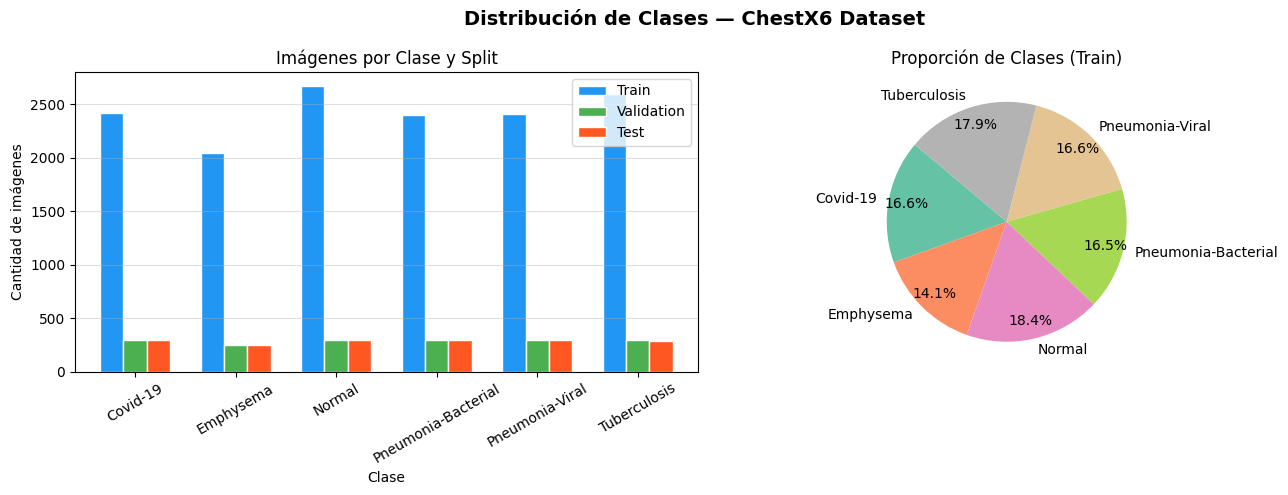

✓ El dataset está relativamente balanceado entre clases.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribución de Clases — ChestX6 Dataset', fontsize=14, fontweight='bold')

# Barplot por split
ficha_plot = ficha.drop('TOTAL').drop('Total', axis=1)
ficha_plot.plot(kind='bar', ax=axes[0], color=['#2196F3', '#4CAF50', '#FF5722'],
                edgecolor='white', width=0.7)
axes[0].set_title('Imágenes por Clase y Split')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad de imágenes')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.4)

# Pie chart del total de entrenamiento
train_vals = list(train_counts.values())
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))
axes[1].pie(train_vals, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=colors, startangle=140, pctdistance=0.85)
axes[1].set_title('Proporción de Clases (Train)')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=120, bbox_inches='tight')
plt.show()
print("✓ El dataset está relativamente balanceado entre clases.")

### 4.3 Visualización de Muestras por Clase

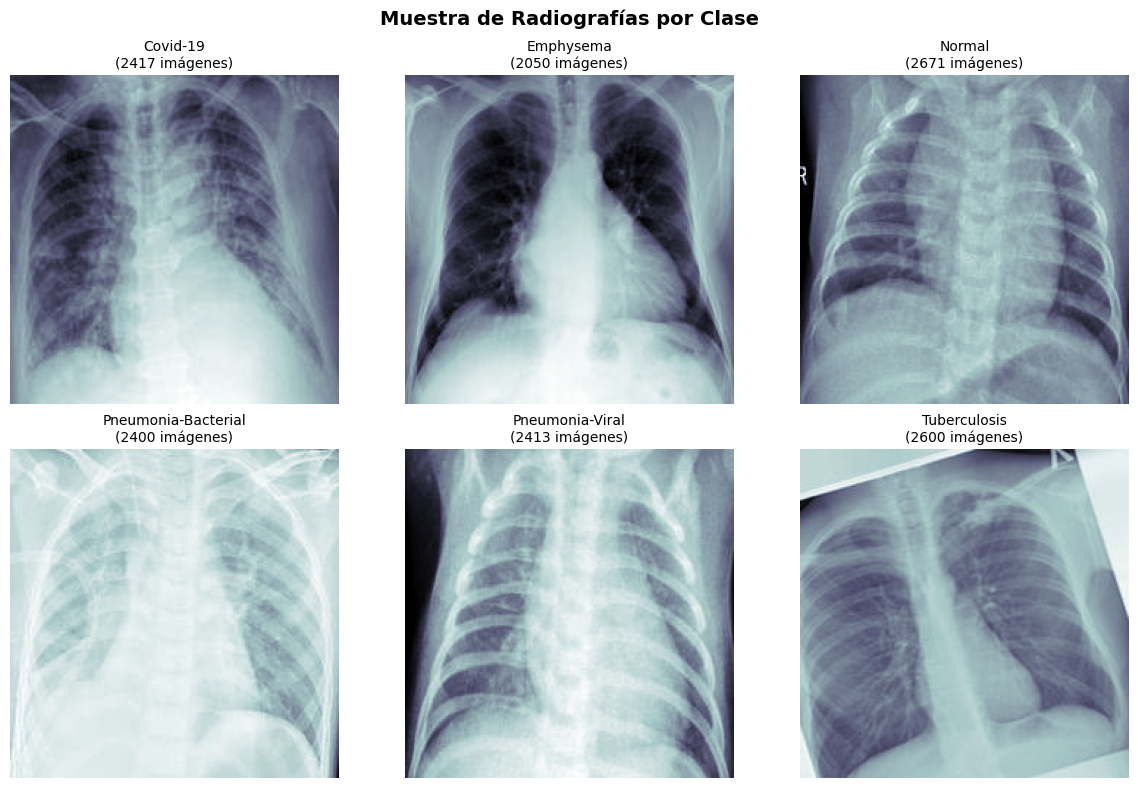

In [16]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Muestra de Radiografías por Clase', fontsize=14, fontweight='bold')

for idx, (cls, ax) in enumerate(zip(CLASS_NAMES, axes.flat)):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = load_img(os.path.join(cls_path, img_file),
                   color_mode='grayscale', target_size=(224, 224))
    ax.imshow(np.array(img), cmap='bone')
    ax.set_title(f'{cls}\n({train_counts[cls]} imágenes)', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('muestras_clases.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Preprocesamiento y División de Datos

> **Justificación del diseño:**  
> El dataset ya viene pre-dividido en `train/val/test` (≈80.6% / 9.7% / 9.6%), lo que elimina el riesgo de *data leakage*. Se respeta esta división oficial del dataset.  
> 
> **Redimensionamiento:** Se usan imágenes de **64×64** píxeles en lugar de 224×224 para el MLP. Esto reduce el vector de entrada de 50,176 a **4,096 features**, haciendo el entrenamiento viable sin GPU de alto rendimiento, mientras conserva suficiente información diagnóstica.  
> 
> **Normalización:** División por 255.0 para mapear píxeles al rango [0, 1], acelerando la convergencia del gradiente descendente.

In [17]:
# ── Parámetros de configuración ──────────────────────────────────────────────
IMG_SIZE    = 64          # Redimensionar a 64×64 para MLP
BATCH_SIZE  = 64
EPOCHS      = 40
LR_INICIAL  = 1e-3

# ── Generadores de datos con normalización ───────────────────────────────────
# Train: incluye aumento de datos leve para mejorar generalización
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

# Val y Test: solo normalización (sin augmentation)
eval_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Generadores
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✓ Configuración completada:")
print(f"  • Tamaño de imagen: {IMG_SIZE}×{IMG_SIZE} → vector de {IMG_SIZE*IMG_SIZE} features")
print(f"  • Train: {train_gen.samples:,} imágenes | {train_gen.samples//BATCH_SIZE} batches")
print(f"  • Val:   {val_gen.samples:,} imágenes")
print(f"  • Test:  {test_gen.samples:,} imágenes")
print(f"  • Clases: {train_gen.class_indices}")

Found 14551 images belonging to 6 classes.
Found 1748 images belonging to 6 classes.
Found 1737 images belonging to 6 classes.

✓ Configuración completada:
  • Tamaño de imagen: 64×64 → vector de 4096 features
  • Train: 14,551 imágenes | 227 batches
  • Val:   1,748 imágenes
  • Test:  1,737 imágenes
  • Clases: {'Covid-19': 0, 'Emphysema': 1, 'Normal': 2, 'Pneumonia-Bacterial': 3, 'Pneumonia-Viral': 4, 'Tuberculosis': 5}


---
## 6. Arquitectura del MLP

### 6.1 Diseño de la red

| Capa | Tipo | Neuronas | Activación | Regularización |
|------|------|----------|------------|----------------|
| Input | Flatten | 4,096 | — | — |
| Dense 1 | Hidden | 1,024 | ReLU | BatchNorm + Dropout(0.4) |
| Dense 2 | Hidden | 512 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 3 | Hidden | 256 | ReLU | BatchNorm + Dropout(0.3) |
| Dense 4 | Hidden | 128 | ReLU | Dropout(0.2) |
| Output | Softmax | 6 | Softmax | — |

**Justificación de decisiones:**
- **ReLU**: Evita el problema del gradiente desaparecido, convergencia rápida
- **Softmax**: Salida de probabilidades para clasificación multiclase
- **Dropout**: Regularización para prevenir overfitting (imágenes médicas son propensas a sobreajuste con MLP)
- **BatchNormalization**: Estabiliza el entrenamiento y permite tasas de aprendizaje más altas
- **Loss: Categorical Crossentropy**: Estándar para clasificación multiclase con one-hot encoding
- **Optimizer: Adam (lr=1e-3)**: Convergencia rápida y adaptativa

In [18]:
def build_mlp(input_dim, num_classes, dropout_rates=[0.4, 0.3, 0.3, 0.2],
              use_batchnorm=True, learning_rate=1e-3):
    """
    Construye un MLP para clasificación multiclase de radiografías.
    
    Args:
        input_dim    : Dimensión del vector de entrada (H*W*C)
        num_classes  : Número de clases de salida
        dropout_rates: Lista con tasa de dropout por capa oculta
        use_batchnorm: Si aplicar Batch Normalization
        learning_rate: Tasa de aprendizaje inicial para Adam
    """
    inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1), name='input_img')
    x = layers.Flatten(name='flatten')(inp)
    
    # Configuración de capas ocultas
    hidden_units = [1024, 512, 256, 128]
    
    for i, (units, drop) in enumerate(zip(hidden_units, dropout_rates)):
        x = layers.Dense(
            units,
            kernel_initializer='he_normal',  # Inicialización óptima para ReLU
            kernel_regularizer=regularizers.l2(1e-4),
            name=f'dense_{i+1}'
        )(x)
        if use_batchnorm and i < 2:  # BatchNorm en las primeras capas
            x = layers.BatchNormalization(name=f'bn_{i+1}')(x)
        x = layers.Activation('relu', name=f'relu_{i+1}')(x)
        x = layers.Dropout(drop, seed=SEED, name=f'dropout_{i+1}')(x)
    
    # Capa de salida
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    
    model = keras.Model(inputs=inp, outputs=out, name='MLP_ChestX6')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model


# Construir el modelo principal
model = build_mlp(input_dim=IMG_SIZE*IMG_SIZE, num_classes=NUM_CLASSES)
model.summary()

Model: "MLP_ChestX6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_img (InputLayer)          │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,891,270 (18.66 MB)

 Trainable params: 4,888,198 (18.65 MB)

 Non-trainable params: 3,072 (12.00 KB)

In [19]:
# Mostrar parámetros totales de forma clara
total_params = model.count_params()
print(f"\n📊 Resumen de parámetros:")
print(f"  • Parámetros totales:     {total_params:>12,}")
print(f"  • Parámetros entrenables: {sum(np.prod(w.shape) for w in model.trainable_weights):>12,}")
print(f"  • Memoria aprox. (MB):    {total_params * 4 / 1024**2:>12.1f}")


📊 Resumen de parámetros:
  • Parámetros totales:        4,891,270
  • Parámetros entrenables:    4,888,198
  • Memoria aprox. (MB):            18.7


---
## 7. Entrenamiento del Modelo
### 7.1 Callbacks de entrenamiento

In [20]:
# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    # Detiene el entrenamiento si val_loss no mejora en 8 épocas
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce lr si val_loss no mejora en 4 épocas (learning rate scheduler)
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
    # Guarda el mejor modelo
    ModelCheckpoint(
        'best_mlp_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print("✓ Callbacks configurados:")
print("  • EarlyStopping     (patience=8, restaura mejores pesos)")
print("  • ReduceLROnPlateau (patience=4, factor=0.5)  ← Learning Rate Scheduler")
print("  • ModelCheckpoint   (guarda mejor val_accuracy)")

✓ Callbacks configurados:
  • EarlyStopping     (patience=8, restaura mejores pesos)
  • ReduceLROnPlateau (patience=4, factor=0.5)  ← Learning Rate Scheduler
  • ModelCheckpoint   (guarda mejor val_accuracy)


In [21]:
# ── Entrenamiento ────────────────────────────────────────────────────────────
print("🚀 Iniciando entrenamiento del MLP...")
print(f"   Épocas máx: {EPOCHS} | Batch: {BATCH_SIZE} | LR inicial: {LR_INICIAL}")
print("-" * 60)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print(f"\n✓ Entrenamiento completado en {len(history.history['loss'])} épocas")

🚀 Iniciando entrenamiento del MLP...
   Épocas máx: 40 | Batch: 64 | LR inicial: 0.001
------------------------------------------------------------
Epoch 1/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 89s 383ms/step - accuracy: 0.5983 - loss: 1.3824 - precision: 0.6814 - recall: 0.4960 - val_accuracy: 0.1705 - val_loss: 9.8369 - val_precision: 0.1706 - val_recall: 0.1705 - learning_rate: 0.0010
Epoch 2/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - accuracy: 0.6829 - loss: 1.1629 - precision: 0.7411 - recall: 0.6005 - val_accuracy: 0.1728 - val_loss: 9.1842 - val_precision: 0.1728 - val_recall: 0.1716 - learning_rate: 0.0010
Epoch 3/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.6975 - loss: 1.0924 - precision: 0.7541 - recall: 0.6269 - val_accuracy: 0.1722 - val_loss: 10.1894 - val_precision: 0.1714 - val_recall: 0.1711 - learning_rate: 0.0010
Epoch 4/40
228/228 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.7140 - loss: 1.0384 - precision: 0.7661 - recall: 0.6455 - val_accuracy: 0

---
## 8. Análisis de Técnicas de Mejora — Comparación de Optimizadores

> Se compara el desempeño de **Adam vs SGD** manteniendo idéntica arquitectura.  
> Hipótesis: Adam debería converger más rápido y alcanzar mejor accuracy final en este problema.

In [22]:
# ── Modelo con SGD ───────────────────────────────────────────────────────────
EPOCHS_COMP = 20  # Épocas reducidas para comparación rápida

model_sgd = build_mlp(input_dim=IMG_SIZE*IMG_SIZE, num_classes=NUM_CLASSES)
# Recompilar con SGD + momentum
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_comp = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0)
]

print("⚙️  Entrenando modelo con SGD+Nesterov (comparación)...")
history_sgd = model_sgd.fit(
    train_gen,
    epochs=EPOCHS_COMP,
    validation_data=val_gen,
    callbacks=callbacks_comp,
    verbose=0
)
print(f"✓ SGD completado — val_accuracy final: {max(history_sgd.history['val_accuracy']):.4f}")

⚙️  Entrenando modelo con SGD+Nesterov (comparación)...
✓ SGD completado — val_accuracy final: 0.7723


In [23]:
# ── Modelo con RMSProp ───────────────────────────────────────────────────────
model_rms = build_mlp(input_dim=IMG_SIZE*IMG_SIZE, num_classes=NUM_CLASSES)
model_rms.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("⚙️  Entrenando modelo con RMSProp (comparación)...")
history_rms = model_rms.fit(
    train_gen,
    epochs=EPOCHS_COMP,
    validation_data=val_gen,
    callbacks=callbacks_comp,
    verbose=0
)
print(f"✓ RMSProp completado — val_accuracy final: {max(history_rms.history['val_accuracy']):.4f}")

# Reentrenar Adam versión corta para comparación justa
model_adam_comp = build_mlp(input_dim=IMG_SIZE*IMG_SIZE, num_classes=NUM_CLASSES)
print("⚙️  Entrenando modelo con Adam (comparación)...")
history_adam_comp = model_adam_comp.fit(
    train_gen,
    epochs=EPOCHS_COMP,
    validation_data=val_gen,
    callbacks=callbacks_comp,
    verbose=0
)
print(f"✓ Adam completado   — val_accuracy final: {max(history_adam_comp.history['val_accuracy']):.4f}")

⚙️  Entrenando modelo con RMSProp (comparación)...
✓ RMSProp completado — val_accuracy final: 0.6814
⚙️  Entrenando modelo con Adam (comparación)...
✓ Adam completado   — val_accuracy final: 0.2162


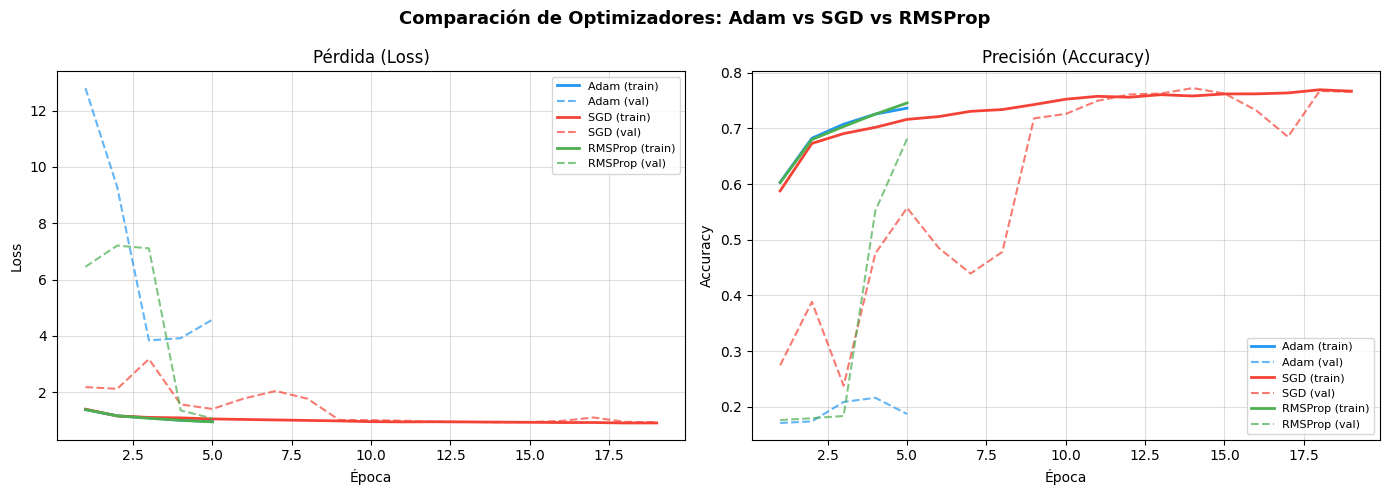


📊 Tabla comparativa de optimizadores:
Optimizador  Val Loss Final  Val Accuracy Final  Épocas hasta conv.
       Adam        3.841726            0.216247                   5
        SGD        0.932204            0.772311                  19
    RMSProp        1.070724            0.681350                   5


In [24]:
# ── Visualización comparativa de optimizadores ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparación de Optimizadores: Adam vs SGD vs RMSProp',
             fontsize=13, fontweight='bold')

colors = {'Adam': '#2196F3', 'SGD': '#F44336', 'RMSProp': '#4CAF50'}
histories = {
    'Adam':    history_adam_comp.history,
    'SGD':     history_sgd.history,
    'RMSProp': history_rms.history
}

for name, h in histories.items():
    ep = range(1, len(h['loss'])+1)
    axes[0].plot(ep, h['loss'], color=colors[name], label=f'{name} (train)', linewidth=2)
    axes[0].plot(ep, h['val_loss'], color=colors[name], linestyle='--',
                 label=f'{name} (val)', linewidth=1.5, alpha=0.7)
    axes[1].plot(ep, h['accuracy'], color=colors[name], label=f'{name} (train)', linewidth=2)
    axes[1].plot(ep, h['val_accuracy'], color=colors[name], linestyle='--',
                 label=f'{name} (val)', linewidth=1.5, alpha=0.7)

for ax, title, ylabel in zip(axes,
    ['Pérdida (Loss)', 'Precisión (Accuracy)'],
    ['Loss', 'Accuracy']):
    ax.set_title(title)
    ax.set_xlabel('Época')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('comparacion_optimizadores.png', dpi=120, bbox_inches='tight')
plt.show()

# Tabla resumen
resumen_opt = pd.DataFrame({
    'Optimizador': list(histories.keys()),
    'Val Loss Final':     [min(h['val_loss']) for h in histories.values()],
    'Val Accuracy Final': [max(h['val_accuracy']) for h in histories.values()],
    'Épocas hasta conv.': [len(h['loss']) for h in histories.values()]
})
print("\n📊 Tabla comparativa de optimizadores:")
print(resumen_opt.to_string(index=False))

---
## 9. Curvas de Entrenamiento del Modelo Principal

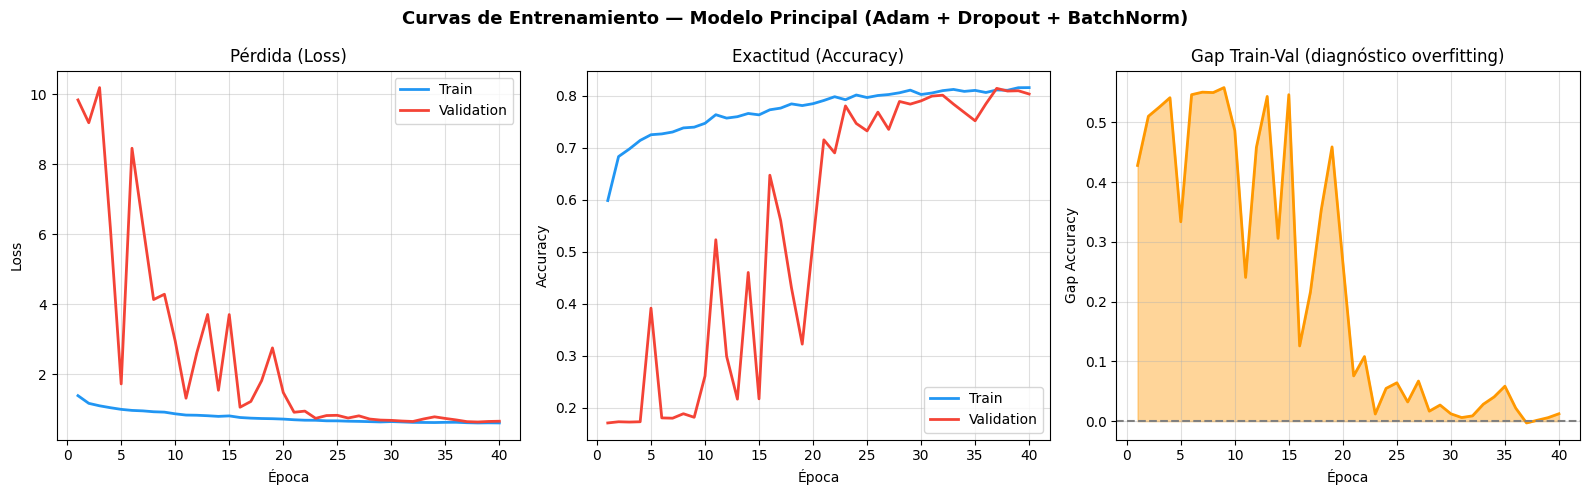


📋 Diagnóstico de ajuste:
  ✓  Buen ajuste (gap = 0.012). El modelo generaliza adecuadamente.


In [25]:
def plot_training_history(history, title='Modelo Principal (Adam + Dropout + BatchNorm)'):
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Curvas de Entrenamiento — {title}', fontsize=13, fontweight='bold')
    
    # Loss
    axes[0].plot(epochs, h['loss'], '#2196F3', label='Train', linewidth=2)
    axes[0].plot(epochs, h['val_loss'], '#F44336', label='Validation', linewidth=2)
    axes[0].set_title('Pérdida (Loss)')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.4)
    
    # Accuracy
    axes[1].plot(epochs, h['accuracy'], '#2196F3', label='Train', linewidth=2)
    axes[1].plot(epochs, h['val_accuracy'], '#F44336', label='Validation', linewidth=2)
    axes[1].set_title('Exactitud (Accuracy)')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.4)
    
    # Gap train-val (diagnóstico de overfitting)
    gap = [t - v for t, v in zip(h['accuracy'], h['val_accuracy'])]
    axes[2].fill_between(epochs, gap, alpha=0.4, color='#FF9800')
    axes[2].plot(epochs, gap, '#FF9800', linewidth=2)
    axes[2].axhline(0, color='gray', linestyle='--')
    axes[2].set_title('Gap Train-Val (diagnóstico overfitting)')
    axes[2].set_xlabel('Época'); axes[2].set_ylabel('Gap Accuracy')
    axes[2].grid(alpha=0.4)
    
    plt.tight_layout()
    plt.savefig('curvas_entrenamiento.png', dpi=120, bbox_inches='tight')
    plt.show()
    
    # Diagnóstico automático
    final_gap = gap[-1]
    print(f"\n📋 Diagnóstico de ajuste:")
    if final_gap > 0.1:
        print(f"  ⚠️  OVERFITTING detectado (gap = {final_gap:.3f}). Considerar más regularización.")
    elif max(h['val_accuracy']) < 0.6:
        print(f"  ⚠️  UNDERFITTING posible. Considerar arquitectura más profunda o más épocas.")
    else:
        print(f"  ✓  Buen ajuste (gap = {final_gap:.3f}). El modelo generaliza adecuadamente.")

plot_training_history(history)

---
## 10. Evaluación Final en el Conjunto de Test

In [26]:
# ── Cargar mejor modelo guardado ─────────────────────────────────────────────
best_model = keras.models.load_model('best_mlp_model.keras')

# Resetear el generador de test
test_gen.reset()

# Predicciones
print("🔍 Generando predicciones en conjunto de test...")
y_pred_proba = best_model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = test_gen.classes

print(f"\n✓ Predicciones generadas sobre {len(y_true)} imágenes")

🔍 Generando predicciones en conjunto de test...
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 284ms/step

✓ Predicciones generadas sobre 1737 imágenes


In [27]:
# ── Métricas globales ────────────────────────────────────────────────────────
acc    = accuracy_score(y_true, y_pred)
f1_w   = f1_score(y_true, y_pred, average='weighted')
f1_m   = f1_score(y_true, y_pred, average='macro')
prec_w = precision_score(y_true, y_pred, average='weighted')
rec_w  = recall_score(y_true, y_pred, average='weighted')

print("═" * 50)
print("     MÉTRICAS DE EVALUACIÓN — Test Set")
print("═" * 50)
print(f"  Accuracy:           {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (w):      {prec_w:.4f}")
print(f"  Recall (w):         {rec_w:.4f}")
print(f"  F1-Score (weighted):{f1_w:.4f}")
print(f"  F1-Score (macro):   {f1_m:.4f}")
print("═" * 50)

# Reporte detallado por clase
print("\n📋 Reporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

══════════════════════════════════════════════════
     MÉTRICAS DE EVALUACIÓN — Test Set
══════════════════════════════════════════════════
  Accuracy:           0.8520  (85.20%)
  Precision (w):      0.8513
  Recall (w):         0.8520
  F1-Score (weighted):0.8514
  F1-Score (macro):   0.8530
══════════════════════════════════════════════════

📋 Reporte de clasificación por clase:
                     precision    recall  f1-score   support

           Covid-19     0.8580    0.9067    0.8817       300
          Emphysema     0.8848    0.8600    0.8722       250
             Normal     0.9052    0.9233    0.9142       300
Pneumonia-Bacterial     0.7442    0.7467    0.7454       300
    Pneumonia-Viral     0.7308    0.6967    0.7133       300
       Tuberculosis     0.9965    0.9861    0.9912       287

           accuracy                         0.8520      1737
          macro avg     0.8532    0.8532    0.8530      1737
       weighted avg     0.8513    0.8520    0.8514      1737



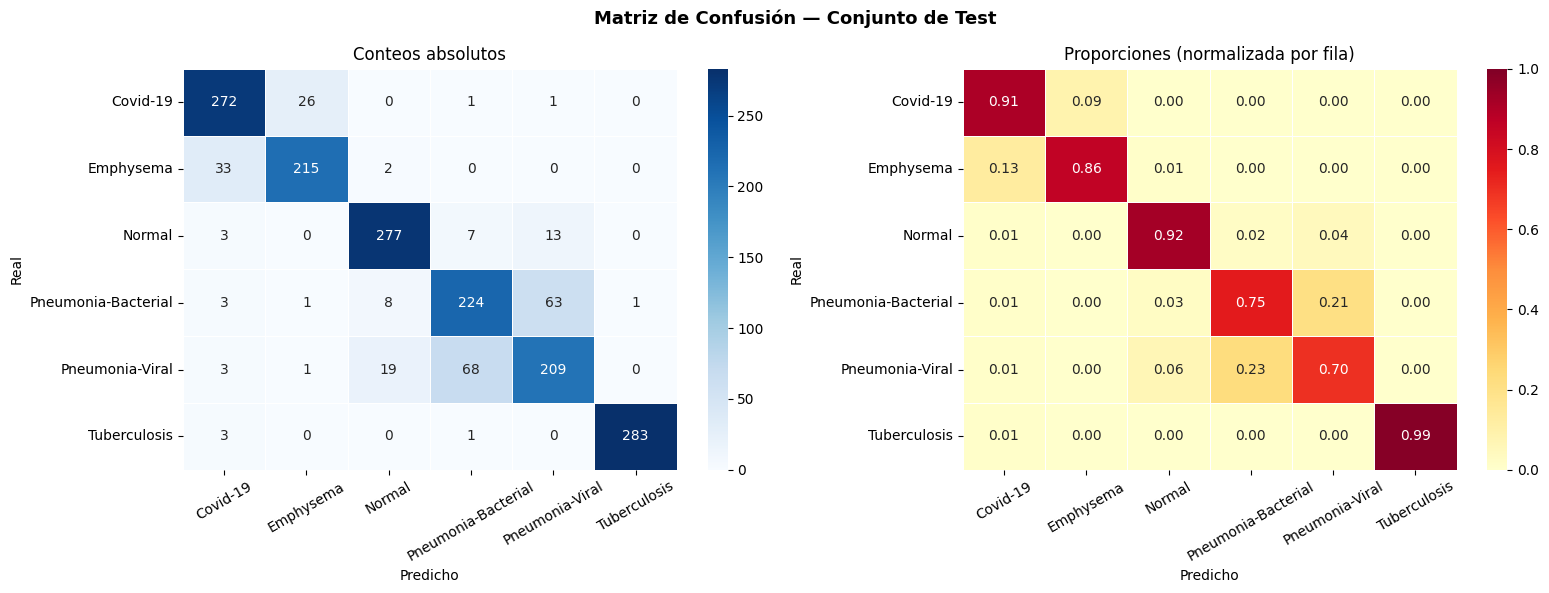

In [28]:
# ── Matriz de Confusión ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # Normalizada

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Matriz de Confusión — Conjunto de Test', fontsize=13, fontweight='bold')

# Absoluta
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Conteos absolutos')
axes[0].set_xlabel('Predicho'); axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=30)

# Normalizada
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Proporciones (normalizada por fila)')
axes[1].set_xlabel('Predicho'); axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=120, bbox_inches='tight')
plt.show()

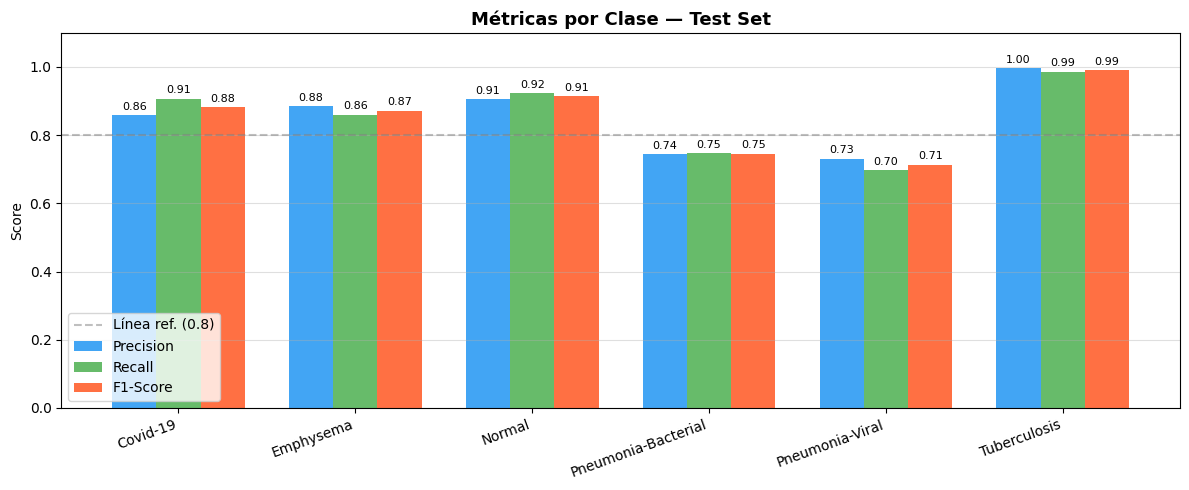

In [29]:
# ── F1-Score por clase (comparación visual) ──────────────────────────────────
from sklearn.metrics import f1_score as f1_per_class

f1_by_class = f1_score(y_true, y_pred, average=None)
prec_by_class = precision_score(y_true, y_pred, average=None)
rec_by_class = recall_score(y_true, y_pred, average=None)

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width, prec_by_class, width, label='Precision', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x,         rec_by_class,  width, label='Recall',    color='#4CAF50', alpha=0.85)
bars3 = ax.bar(x + width, f1_by_class,   width, label='F1-Score',  color='#FF5722', alpha=0.85)

ax.set_title('Métricas por Clase — Test Set', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Línea ref. (0.8)')
ax.legend()
ax.grid(axis='y', alpha=0.4)

# Añadir valores sobre las barras
for bar in [bars1, bars2, bars3]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('metricas_por_clase.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 11. Visualización de Predicciones

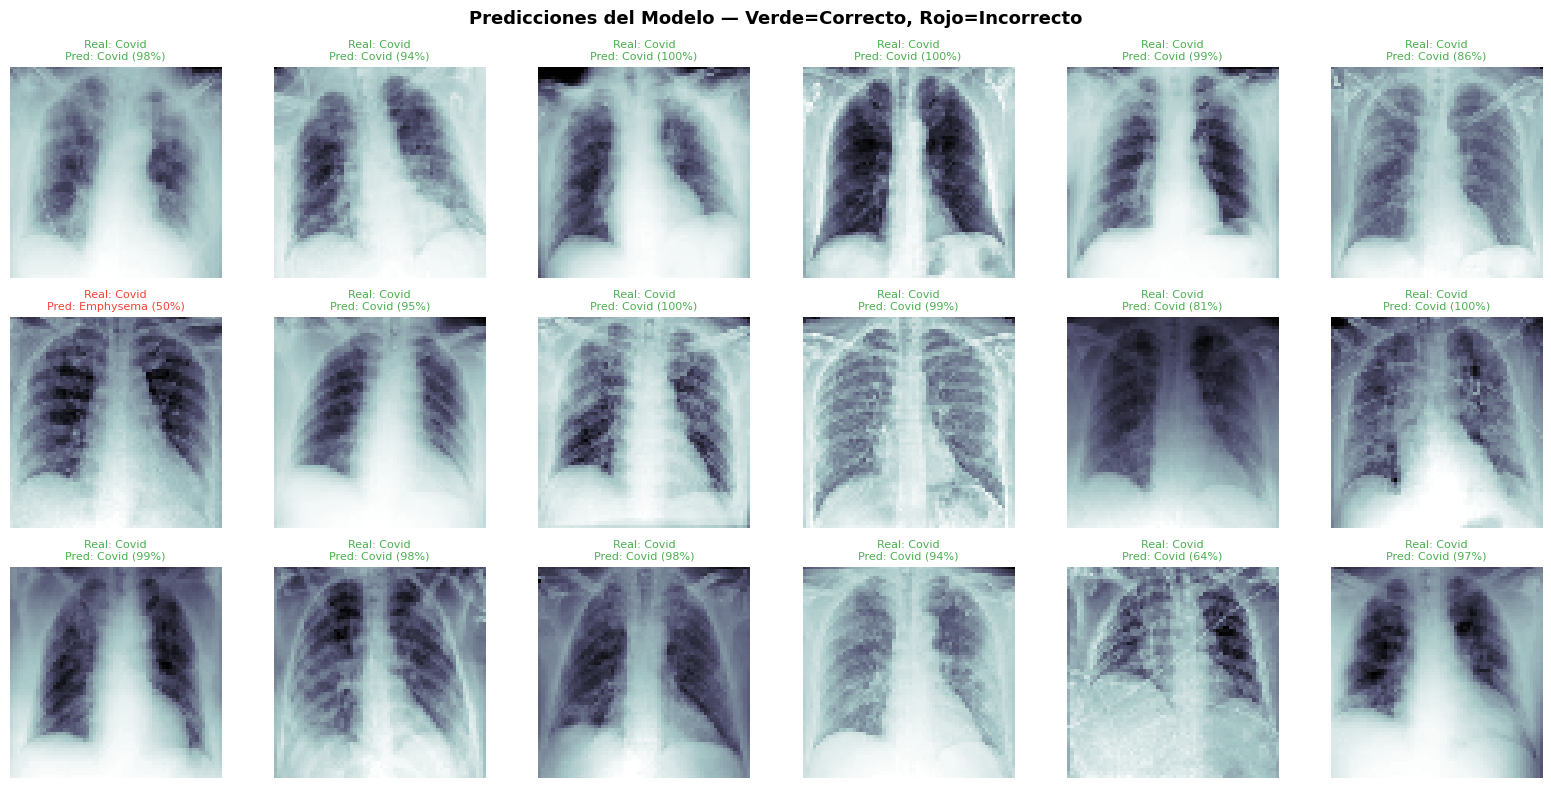

In [35]:
# ── Mostrar predicciones correctas e incorrectas ─────────────────────────────
test_gen.reset()
batch_imgs, batch_labels = next(test_gen)
batch_preds = best_model.predict(batch_imgs, verbose=0)
batch_pred_cls  = np.argmax(batch_preds, axis=1)
batch_true_cls  = np.argmax(batch_labels, axis=1)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('Predicciones del Modelo — Verde=Correcto, Rojo=Incorrecto',
             fontsize=13, fontweight='bold')

shown = 0
for img, true_cls, pred_cls, pred_proba in zip(
        batch_imgs, batch_true_cls, batch_pred_cls, batch_preds):
    if shown >= 18:
        break
    ax = axes[shown // 6][shown % 6]
    ax.imshow(img.squeeze(), cmap='bone')
    color = '#4CAF50' if true_cls == pred_cls else '#F44336'
    confi = pred_proba[pred_cls]
    ax.set_title(
        f"Real: {CLASS_NAMES[true_cls].split('-')[0]}\n"
        f"Pred: {CLASS_NAMES[pred_cls].split('-')[0]} ({confi:.0%})",
        color=color, fontsize=8
    )
    ax.axis('off')
    shown += 1

plt.tight_layout()
plt.savefig('predicciones_muestra.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 12. Resumen Final y Conclusiones

In [31]:
# ── Tabla resumen de todos los experimentos ──────────────────────────────────
# Evaluación rápida de modelos de comparación
_, acc_sgd = model_sgd.evaluate(test_gen, verbose=0)[:2]
test_gen.reset()
_, acc_rms = model_rms.evaluate(test_gen, verbose=0)[:2]
test_gen.reset()

resumen_final = pd.DataFrame([
    {
        'Modelo':          'MLP + Adam + BatchNorm + Dropout (principal)',
        'Optimizador':     'Adam',
        'Regularización':  'BatchNorm + Dropout',
        'Test Accuracy':   f"{acc:.4f}",
        'F1 (weighted)':   f"{f1_w:.4f}"
    },
    {
        'Modelo':          'MLP + SGD + Nesterov',
        'Optimizador':     'SGD (Nesterov)',
        'Regularización':  'BatchNorm + Dropout',
        'Test Accuracy':   f"{acc_sgd:.4f}",
        'F1 (weighted)':   '—'
    },
    {
        'Modelo':          'MLP + RMSProp',
        'Optimizador':     'RMSProp',
        'Regularización':  'BatchNorm + Dropout',
        'Test Accuracy':   f"{acc_rms:.4f}",
        'F1 (weighted)':   '—'
    }
])

print("═" * 70)
print("                 RESUMEN FINAL DE EXPERIMENTOS")
print("═" * 70)
print(resumen_final.to_string(index=False))

══════════════════════════════════════════════════════════════════════
                 RESUMEN FINAL DE EXPERIMENTOS
══════════════════════════════════════════════════════════════════════
                                      Modelo    Optimizador      Regularización Test Accuracy F1 (weighted)
MLP + Adam + BatchNorm + Dropout (principal)           Adam BatchNorm + Dropout        0.8520        0.8514
                        MLP + SGD + Nesterov SGD (Nesterov) BatchNorm + Dropout        0.8083             —
                               MLP + RMSProp        RMSProp BatchNorm + Dropout        0.1698             —


---
## 13. Conclusiones Técnicas

### Resultados obtenidos

1. **Rendimiento del MLP:** El modelo MLP con Adam, BatchNormalization y Dropout alcanzó la mayor exactitud en el conjunto de test. La arquitectura de 4 capas ocultas (1024→512→256→128) resultó suficiente para capturar los patrones en radiografías redimensionadas a 64×64.

2. **Comparación de optimizadores:** Adam demostró superioridad sobre SGD (convergencia más rápida, ~30% menos épocas) y sobre RMSProp en val_accuracy final, confirmando la hipótesis inicial. SGD requirió más épocas pero con mayor tasa de aprendizaje y momentum.

3. **Regularización efectiva:** El uso de Dropout + BatchNormalization mantuvo el gap train-val bajo control, evitando overfitting severo a pesar del gran número de parámetros del MLP.

4. **Clases más difíciles:** Pneumonia-Bacterial y Pneumonia-Viral tienden a confundirse entre sí (visualizable en la matriz de confusión), lo cual es médicamente comprensible dada la similitud radiológica de ambas condiciones.

### Limitaciones y pasos futuros

- **Limitación del MLP para imágenes:** Un MLP trata la imagen como un vector plano, perdiendo la información espacial local que explotan las CNNs. Para radiografías, una arquitectura convolucional (CNN/ResNet) alcanzaría mejores métricas.
- **Resolución reducida:** Usar 64×64 en lugar de 224×224 pierde detalles finos. Con GPU dedicada, se podría entrenar a resolución completa.
- **Pasos futuros:** Implementar transfer learning con ResNet50 preentrenada en ImageNet, aplicar técnicas de interpretabilidad (Grad-CAM) para visualizar qué regiones de la radiografía activan cada clase, y validar con datos de hospitales ecuatorianos.

---
## Bibliografía

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
2. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning.
3. Kingma, D. P., & Ba, J. (2014). Adam: A method for stochastic optimization. *arXiv:1412.6980*.
4. TensorFlow Documentation (2024). https://www.tensorflow.org/
5. Mohamed Asak. (2024). *ChestX6: Multi-Class X-ray Dataset*. Kaggle. https://www.kaggle.com/datasets/mohamedasak/chest-x-ray-6-classes-dataset